# **PUC-Rio | Departamento de Engenharia Industrial**
# **ENG 4560: Projeto Integrado VI - Distribuição Física**

---

# **Aula 7 — Heurísticas construtivas - Clarke-Wright Savings**  
**Prof. Marcello Congro (marcellocongro@puc-rio.br)**

---

### **Objetivo desta aula prática**

Na Sprint 1, construímos e analisamos modelos exatos para o CVRP, observando que eles são conceitualmente poderosos, mas podem se tornar computacionalmente caros quando o problema cresce. Nesta aula, passamos a trabalhar com heurísticas construtivas, isto é, métodos capazes de gerar rapidamente soluções viáveis para o mesmo problema.

O foco permanece o mesmo: as instâncias derivadas do caso real da Prolog, já tratadas nas aulas anteriores.

### **O que faremos aqui**

1. Carregar uma instância já preparada;
2. Implementar uma heurística simples de construção de rotas (Nearest Neighbor);
3. Implementar uma heurística mais estruturada (Clarke–Wright Savings);
4. Comparar as soluções obtidas em termos de:
   - custo total,
   - distância percorrida,
   - número de veículos,
   - tempo computacional;
5. Discutir vantagens e limitações de cada abordagem.

### **Como trabalhar neste notebook**

Este material foi estruturado como estudo guiado.

Recomenda-se:

1. Ler antes de executar;
2. Discutir em grupo as perguntas indicadas;
3. Implementar cuidadosamente os trechos marcados como `TODO`;
4. Comparar criticamente os resultados, em vez de apenas registrar números.

Evite executar todas as células de uma vez.

In [ ]:
# ============================================================
# (1) IMPORTAÇÕES E PREPARAÇÃO DO AMBIENTE
# ============================================================
# Nesta aula, vamos implementar a heurística de Clarke-Wright Savings
# em uma versão adaptada para frota heterogênea.
#
# Ideia central:
# 1) começar com uma rota por cliente;
# 2) calcular os savings entre pares de clientes;
# 3) tentar fundir rotas em ordem decrescente de saving;
# 4) sempre que surgir uma rota candidata, testar os veículos disponíveis;
# 5) aceitar a fusão apenas se a nova rota for viável em termos de:
#    - capacidade
#    - jornada máxima
# 6) escolher o veículo mais vantajoso para a rota fundida.
#
# Assim, a decisão sobre o veículo deixa de ser feita apenas no final
# e passa a fazer parte da própria heurística construtiva.

import numpy as np
import pandas as pd
import json
import os
import time
import math
import matplotlib.pyplot as plt

from google.colab import files

In [ ]:
# ============================================================
# (2) UPLOAD DA INSTÂNCIA
# ============================================================
# Faça upload dos arquivos da instância:
# - nodes.csv
# - D.npy
# - Cvar.npy
# - q.npy
# - s.npy
# - params.json

!rm -f *.csv *.npy *.json

print("Faça upload dos arquivos da instância.")
uploaded = files.upload()

print("\nArquivos disponíveis no ambiente:")
print(os.listdir())

Faça upload dos arquivos da instância.


Saving Cvar.npy to Cvar.npy
Saving D.npy to D.npy
Saving nodes.csv to nodes.csv
Saving params.json to params.json
Saving q.npy to q.npy
Saving s.npy to s.npy
Saving Tmov_h.npy to Tmov_h.npy

Arquivos disponíveis no ambiente:
['.config', 'D.npy', 'nodes.csv', 'params.json', 'Cvar.npy', 'q.npy', 'Tmov_h.npy', 's.npy', 'sample_data']


In [ ]:
# ============================================================
# (3) LEITURA E VALIDAÇÃO DA INSTÂNCIA
# ============================================================
# Antes de aplicar a heurística, verificamos se a instância foi
# carregada corretamente e se as dimensões são compatíveis.

nodes = pd.read_csv("nodes.csv")
D = np.load("D.npy")          # matriz de distâncias (km)
Cvar = np.load("Cvar.npy")    # matriz de custo variável (não será usada diretamente)
q = np.load("q.npy")          # demandas (kg)
s = np.load("s.npy")          # tempos de serviço (h)

params = json.loads(open("params.json", "r").read())

n = len(nodes)

assert D.shape == (n, n), "Dimensão incorreta da matriz D"
assert Cvar.shape == (n, n), "Dimensão incorreta da matriz Cvar"
assert q.shape == (n,), "Dimensão incorreta do vetor q"
assert s.shape == (n,), "Dimensão incorreta do vetor s"
assert nodes.loc[0, "id"] == 0, "O depósito deve ter id = 0"

print(f"Instância carregada com sucesso: {n-1} clientes + depósito")

Instância carregada com sucesso: 40 clientes + depósito


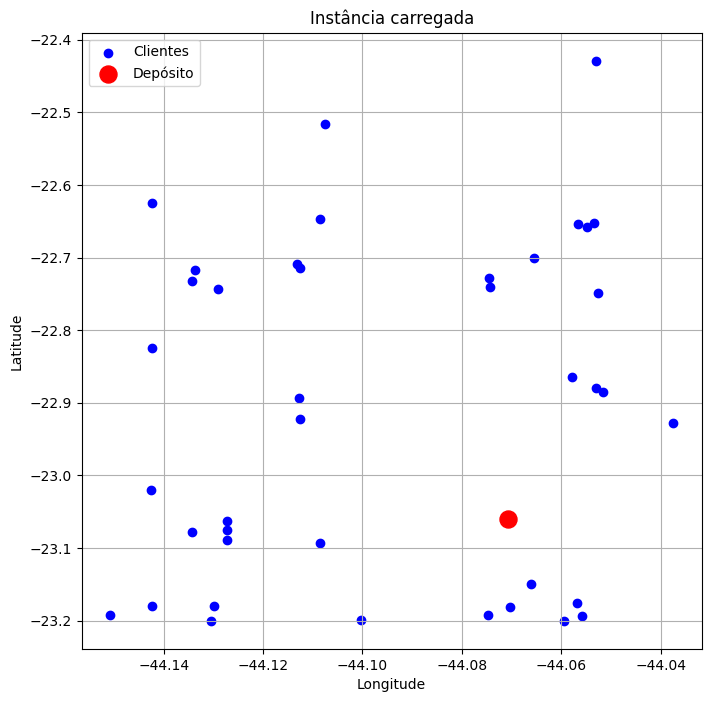

In [ ]:
# ============================================================
# (4) VISUALIZAÇÃO INICIAL DA INSTÂNCIA
# ============================================================
# Antes de construir as rotas, vale observar como os clientes estão
# distribuídos no espaço e onde se localiza o depósito.

x_coords = nodes["lon"].values
y_coords = nodes["lat"].values

plt.figure(figsize=(8, 8))
plt.scatter(x_coords[1:], y_coords[1:], color="blue", label="Clientes")
plt.scatter(x_coords[0], y_coords[0], color="red", s=150, label="Depósito")
plt.title("Instância carregada")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# ============================================================
# (5) PARÂMETROS LOGÍSTICOS
# ============================================================
# Nesta aula vamos trabalhar com dois tipos de veículos:
# - FIO: menor capacidade e menor custo fixo
# - VUC: maior capacidade e maior custo fixo
#
# Também definimos:
# - custo variável por km
# - velocidade média
# - jornada máxima

Q = {
    "FIO": 650.0,
    "VUC": 3000.0
}

f = {
    "FIO": 250.0,
    "VUC": 550.0
}

cost_per_km = 1.50
v_kmh = 40.0
H = 8.0

T = D / v_kmh

print("Capacidades:", Q)
print("Custos fixos:", f)
print("Custo variável por km:", cost_per_km)
print("Velocidade média (km/h):", v_kmh)
print("Jornada máxima (h):", H)

Capacidades: {'FIO': 650.0, 'VUC': 3000.0}
Custos fixos: {'FIO': 250.0, 'VUC': 550.0}
Custo variável por km: 1.5
Velocidade média (km/h): 40.0
Jornada máxima (h): 8.0


In [ ]:
# ============================================================
# (6) FUNÇÕES AUXILIARES DE ROTA
# ============================================================
# Estas funções calculam medidas importantes de uma rota:
# - distância
# - carga
# - tempo de serviço
# - tempo total
# - custo

def route_distance(route, D):
    dist = 0.0
    for a in range(len(route) - 1):
        i = route[a]
        j = route[a + 1]
        dist += D[i, j]
    return dist

def route_load(route, q):
    clients = [node for node in route if node != 0]
    return sum(q[i] for i in clients)

def route_service_time(route, s):
    clients = [node for node in route if node != 0]
    return sum(s[i] for i in clients)

def route_total_time(route, D, s, v_kmh):
    dist = route_distance(route, D)
    t_mov = dist / v_kmh
    t_serv = route_service_time(route, s)
    t_total = t_mov + t_serv
    return t_total, t_mov, t_serv

def route_cost(route, vehicle_type, D, cost_per_km, fixed_costs):
    dist = route_distance(route, D)
    return fixed_costs[vehicle_type] + dist * cost_per_km

In [ ]:
# ============================================================
# (7) AVALIAÇÃO DE UMA ROTA CANDIDATA
# ============================================================
# Dada uma rota candidata, vamos verificar:
# - se ela cabe em cada tipo de veículo;
# - se respeita a jornada;
# - quanto custa;
# - qual é o custo por cliente.
#
# Isso será usado:
# - nas rotas iniciais [0, i, 0];
# - nas rotas fundidas ao longo do Savings.

def evaluate_route_for_vehicle(route, vehicle_type, D, q, s, Q, f, cost_per_km, v_kmh, H):
    load = route_load(route, q)
    total_time, travel_time, service_time = route_total_time(route, D, s, v_kmh)
    distance = route_distance(route, D)
    n_clients = len([node for node in route if node != 0])

    feasible = (load <= Q[vehicle_type]) and (total_time <= H)

    if feasible:
        total_cost = route_cost(route, vehicle_type, D, cost_per_km, f)
        cost_per_client = total_cost / n_clients if n_clients > 0 else math.inf
    else:
        total_cost = math.inf
        cost_per_client = math.inf

    return {
        "vehicle": vehicle_type,
        "route": route,
        "feasible": feasible,
        "n_clients": n_clients,
        "load": load,
        "distance_km": distance,
        "total_time_h": total_time,
        "travel_time_h": travel_time,
        "service_time_h": service_time,
        "total_cost_rs": total_cost,
        "cost_per_client_rs": cost_per_client
    }

In [ ]:
# ============================================================
# (8) ESCOLHA DO MELHOR VEÍCULO PARA UMA ROTA
# ============================================================
# Para uma rota candidata, testamos FIO e VUC.
# Mantemos apenas os veículos viáveis e escolhemos o melhor segundo
# o critério adotado.
#
# Critérios possíveis:
# - "total_cost"
# - "cost_per_client"

def choose_best_vehicle_for_route(route, D, q, s, Q, f, cost_per_km, v_kmh, H, criterion="total_cost"):
    candidates = []

    for vehicle in Q:
        eval_data = evaluate_route_for_vehicle(
            route=route,
            vehicle_type=vehicle,
            D=D,
            q=q,
            s=s,
            Q=Q,
            f=f,
            cost_per_km=cost_per_km,
            v_kmh=v_kmh,
            H=H
        )

        if eval_data["feasible"]:
            candidates.append(eval_data)

    if len(candidates) == 0:
        return None

    if criterion == "total_cost":
        best = min(
            candidates,
            key=lambda x: (x["total_cost_rs"], -x["n_clients"], x["distance_km"])
        )

    elif criterion == "cost_per_client":
        best = min(
            candidates,
            key=lambda x: (x["cost_per_client_rs"], -x["n_clients"], x["total_cost_rs"])
        )

    else:
        raise ValueError("Critério inválido. Use 'total_cost' ou 'cost_per_client'.")

    return best

In [ ]:
# ============================================================
# (9) CHECAGEM DE VIABILIDADE INDIVIDUAL
# ============================================================
# Antes de iniciar a solução, verificamos se cada cliente pode ser
# atendido sozinho na rota [0, i, 0].
#
# Isso ajuda a identificar clientes inviáveis por:
# - capacidade
# - jornada

for vehicle in Q:
    infeasible_capacity = []
    infeasible_time = []

    for j in range(1, len(q)):
        if q[j] > Q[vehicle]:
            infeasible_capacity.append(j)
            continue

        single_route = [0, j, 0]
        t_total, _, _ = route_total_time(single_route, D, s, v_kmh)

        if t_total > H:
            infeasible_time.append(j)

    print(f"\nVeículo: {vehicle}")
    print("Clientes inviáveis por capacidade:", infeasible_capacity)
    print("Clientes inviáveis por jornada individual:", infeasible_time)


Veículo: FIO
Clientes inviáveis por capacidade: [3]
Clientes inviáveis por jornada individual: []

Veículo: VUC
Clientes inviáveis por capacidade: []
Clientes inviáveis por jornada individual: []


In [ ]:
# ============================================================
# (10) CONSTRUÇÃO DA SOLUÇÃO INICIAL
# ============================================================
# A solução inicial do Clarke-Wright é composta por uma rota por cliente:
# [0, i, 0]
#
# Aqui, desde o início, cada rota já recebe o melhor veículo viável.

def build_initial_solution(q, D, s, Q, f, cost_per_km, v_kmh, H, criterion="total_cost"):
    solution = []

    for i in range(1, len(q)):
        route = [0, i, 0]

        best_vehicle = choose_best_vehicle_for_route(
            route=route,
            D=D,
            q=q,
            s=s,
            Q=Q,
            f=f,
            cost_per_km=cost_per_km,
            v_kmh=v_kmh,
            H=H,
            criterion=criterion
        )

        if best_vehicle is None:
            raise ValueError(
                f"O cliente {i} não pode ser atendido por nenhum veículo, "
                "mesmo sozinho."
            )

        solution.append({
            "route": route,
            "vehicle": best_vehicle["vehicle"]
        })

    return solution

In [ ]:
# ============================================================
# (11) CÁLCULO DOS SAVINGS
# ============================================================
# O saving entre dois clientes i e j é dado por:
#
# s_ij = d(0,i) + d(0,j) - d(i,j)
#
# Quanto maior esse valor, maior tende a ser o ganho ao unir esses
# clientes em uma mesma rota.

def compute_savings(D):
    savings = []

    for i in range(1, D.shape[0]):
        for j in range(i + 1, D.shape[0]):
            sij = D[0, i] + D[0, j] - D[i, j]
            savings.append((i, j, sij))

    savings.sort(key=lambda x: x[2], reverse=True)
    return savings

savings_list = compute_savings(D)

print("Número de pares de savings:", len(savings_list))
print("Primeiros 10 savings:")
for item in savings_list[:10]:
    print(item)

Número de pares de savings: 780
Primeiros 10 savings:
(22, 37, np.float64(119.53200330461543))
(18, 37, np.float64(96.82555760424984))
(18, 22, np.float64(95.39875436853467))
(24, 37, np.float64(92.1484633481399))
(22, 24, np.float64(91.3942616616558))
(18, 24, np.float64(90.76502983429856))
(22, 34, np.float64(90.52648548706097))
(22, 33, np.float64(90.31193832682256))
(33, 34, np.float64(90.07991679363401))
(34, 37, np.float64(89.63924423892622))


In [ ]:
# ============================================================
# (12) FUNÇÕES AUXILIARES PARA FUSÃO DE ROTAS
# ============================================================
# No Clarke-Wright, só podemos fundir duas rotas se:
# - os clientes estiverem em rotas diferentes;
# - os clientes estiverem nas extremidades das rotas;
# - a fusão gerar uma sequência válida.
#
# Nesta célula, criamos funções auxiliares para localizar rotas,
# verificar extremidades e construir a rota fundida candidata.

def find_route_containing_customer(solution, customer):
    for idx, item in enumerate(solution):
        route = item["route"]
        if customer in route:
            return idx
    return None

def is_customer_at_route_end(route, customer):
    # Em uma rota [0, ..., 0], as extremidades de clientes são:
    # posição 1 e posição -2
    return (route[1] == customer) or (route[-2] == customer)

def merge_routes_if_possible(route_i, i, route_j, j):
    # Esta função tenta fundir duas rotas se i e j estiverem em extremidades.
    #
    # Exemplos possíveis:
    # [0, ..., i, 0] + [0, j, ..., 0]
    # [0, i, ..., 0] + [0, ..., j, 0]
    #
    # A função reorganiza as rotas quando necessário para permitir a fusão.

    r1 = route_i[:]
    r2 = route_j[:]

    # Garantir que i esteja no final de r1
    if r1[1] == i:
        r1 = r1[::-1]

    # Garantir que j esteja no início de r2
    if r2[-2] == j:
        r2 = r2[::-1]

    # Agora verificamos se ficou no formato esperado
    if r1[-2] != i:
        return None

    if r2[1] != j:
        return None

    # Remove o depósito final da primeira e o inicial da segunda
    merged = r1[:-1] + r2[1:]

    return merged

In [ ]:
# ============================================================
# (13) TENTATIVA DE FUSÃO DE DUAS ROTAS
# ============================================================
# Dadas duas rotas e um par (i, j), tentamos:
# 1) verificar se i e j estão em extremidades;
# 2) construir a rota fundida candidata;
# 3) testar a rota com FIO e VUC;
# 4) escolher o melhor veículo viável.
#
# Se não houver fusão viável, a função retorna None.

def try_merge_routes(
    route_i, i, route_j, j,
    D, q, s, Q, f, cost_per_km, v_kmh, H,
    criterion="total_cost"
):
    if not is_customer_at_route_end(route_i, i):
        return None

    if not is_customer_at_route_end(route_j, j):
        return None

    merged_route = merge_routes_if_possible(route_i, i, route_j, j)

    if merged_route is None:
        return None

    best_vehicle = choose_best_vehicle_for_route(
        route=merged_route,
        D=D,
        q=q,
        s=s,
        Q=Q,
        f=f,
        cost_per_km=cost_per_km,
        v_kmh=v_kmh,
        H=H,
        criterion=criterion
    )

    if best_vehicle is None:
        return None

    return {
        "route": merged_route,
        "vehicle": best_vehicle["vehicle"]
    }

In [ ]:
# ============================================================
# (14) CLARKE-WRIGHT SAVINGS COM FROTA HETEROGÊNEA
# ============================================================
# Agora implementamos a heurística completa.
#
# Passos:
# 1) construir a solução inicial com uma rota por cliente;
# 2) calcular os savings;
# 3) percorrer os pares em ordem decrescente de saving;
# 4) localizar as rotas dos clientes i e j;
# 5) se estiverem em rotas diferentes, tentar a fusão;
# 6) se a fusão for viável, substituir as duas rotas antigas pela nova.

def clarke_wright_heterogeneous(
    D, q, s, Q, f, cost_per_km, v_kmh, H,
    criterion="total_cost", verbose=True
):
    solution = build_initial_solution(
        q=q,
        D=D,
        s=s,
        Q=Q,
        f=f,
        cost_per_km=cost_per_km,
        v_kmh=v_kmh,
        H=H,
        criterion=criterion
    )

    savings_list = compute_savings(D)

    for i, j, sij in savings_list:
        idx_i = find_route_containing_customer(solution, i)
        idx_j = find_route_containing_customer(solution, j)

        # Os clientes precisam estar em rotas diferentes
        if idx_i is None or idx_j is None or idx_i == idx_j:
            continue

        route_i = solution[idx_i]["route"]
        route_j = solution[idx_j]["route"]

        merged = try_merge_routes(
            route_i=route_i,
            i=i,
            route_j=route_j,
            j=j,
            D=D,
            q=q,
            s=s,
            Q=Q,
            f=f,
            cost_per_km=cost_per_km,
            v_kmh=v_kmh,
            H=H,
            criterion=criterion
        )

        if merged is not None:
            # Remover primeiro o maior índice evita deslocamento incorreto
            for idx in sorted([idx_i, idx_j], reverse=True):
                solution.pop(idx)

            solution.append(merged)

            if verbose:
                print(f"Fusão aceita para o par ({i}, {j}) com saving = {round(sij, 2)}")
                print("  nova rota:", merged["route"])
                print("  veículo escolhido:", merged["vehicle"])
                print()

    # Ao final, numeramos as rotas
    final_solution = []
    for rid, item in enumerate(solution, start=1):
        route = item["route"]
        vehicle = item["vehicle"]

        eval_data = evaluate_route_for_vehicle(
            route=route,
            vehicle_type=vehicle,
            D=D,
            q=q,
            s=s,
            Q=Q,
            f=f,
            cost_per_km=cost_per_km,
            v_kmh=v_kmh,
            H=H
        )

        final_solution.append({
            "route_id": rid,
            "route": route,
            "vehicle": vehicle,
            "n_clients": eval_data["n_clients"],
            "load": eval_data["load"],
            "distance_km": eval_data["distance_km"],
            "total_time_h": eval_data["total_time_h"],
            "total_cost_rs": eval_data["total_cost_rs"],
            "cost_per_client_rs": eval_data["cost_per_client_rs"]
        })

    return final_solution

In [ ]:
# ============================================================
# (15) DEFINIÇÃO DO CRITÉRIO DE DECISÃO
# ============================================================
# Critérios possíveis:
# - "total_cost"
# - "cost_per_client"

criterion = "total_cost"

print("Critério adotado:", criterion)

Critério adotado: total_cost


In [ ]:
# ============================================================
# (16) EXECUÇÃO DO CLARKE-WRIGHT HETEROGÊNEO
# ============================================================

start = time.time()

solution_cw_het = clarke_wright_heterogeneous(
    D=D,
    q=q,
    s=s,
    Q=Q,
    f=f,
    cost_per_km=cost_per_km,
    v_kmh=v_kmh,
    H=H,
    criterion=criterion,
    verbose=True
)

elapsed = time.time() - start

print("Tempo computacional (s):", elapsed)

Fusão aceita para o par (22, 37) com saving = 119.53
  nova rota: [0, 22, 37, 0]
  veículo escolhido: FIO

Fusão aceita para o par (18, 37) com saving = 96.83
  nova rota: [0, 18, 37, 22, 0]
  veículo escolhido: FIO

Fusão aceita para o par (22, 24) com saving = 91.39
  nova rota: [0, 18, 37, 22, 24, 0]
  veículo escolhido: FIO

Fusão aceita para o par (33, 34) com saving = 90.08
  nova rota: [0, 33, 34, 0]
  veículo escolhido: FIO

Fusão aceita para o par (29, 34) com saving = 89.51
  nova rota: [0, 29, 34, 33, 0]
  veículo escolhido: FIO

Fusão aceita para o par (24, 33) com saving = 85.87
  nova rota: [0, 18, 37, 22, 24, 33, 34, 29, 0]
  veículo escolhido: FIO

Fusão aceita para o par (4, 29) com saving = 79.59
  nova rota: [0, 4, 29, 34, 33, 24, 22, 37, 18, 0]
  veículo escolhido: FIO

Fusão aceita para o par (18, 31) com saving = 78.28
  nova rota: [0, 4, 29, 34, 33, 24, 22, 37, 18, 31, 0]
  veículo escolhido: FIO

Fusão aceita para o par (31, 32) com saving = 77.33
  nova rota: [

In [ ]:
# ============================================================
# (17) MÉTRICAS GERAIS DA SOLUÇÃO
# ============================================================

def solution_metrics_heterogeneous(solution, D, q, s, cost_per_km, fixed_costs, H, v_kmh):
    total_dist = 0.0
    total_cost = 0.0
    total_time = 0.0
    violations = 0

    vehicle_count = {"FIO": 0, "VUC": 0}

    for item in solution:
        route = item["route"]
        vehicle = item["vehicle"]

        dist = route_distance(route, D)
        t_total, _, _ = route_total_time(route, D, s, v_kmh)
        cost = route_cost(route, vehicle, D, cost_per_km, fixed_costs)

        total_dist += dist
        total_time += t_total
        total_cost += cost
        vehicle_count[vehicle] += 1

        if t_total > H + 1e-6:
            violations += 1

    return {
        "n_routes": len(solution),
        "n_fio": vehicle_count["FIO"],
        "n_vuc": vehicle_count["VUC"],
        "total_distance_km": total_dist,
        "total_cost_rs": total_cost,
        "total_time_h": total_time,
        "routes_violating_H": violations
    }

metrics_cw = solution_metrics_heterogeneous(
    solution=solution_cw_het,
    D=D,
    q=q,
    s=s,
    cost_per_km=cost_per_km,
    fixed_costs=f,
    H=H,
    v_kmh=v_kmh
)

print("Métricas gerais da solução:")
print(metrics_cw)

Métricas gerais da solução:
{'n_routes': 3, 'n_fio': 2, 'n_vuc': 1, 'total_distance_km': np.float64(268.53006609179545), 'total_cost_rs': np.float64(1452.7950991376933), 'total_time_h': np.float64(16.713251652294886), 'routes_violating_H': 0}


In [ ]:
# ============================================================
# (18) TABELA RESUMO DAS ROTAS
# ============================================================

summary_rows = []

for item in solution_cw_het:
    summary_rows.append({
        "route_id": item["route_id"],
        "vehicle": item["vehicle"],
        "route": str(item["route"]),
        "n_clients": item["n_clients"],
        "load_kg": round(item["load"], 2),
        "distance_km": round(item["distance_km"], 2),
        "total_time_h": round(item["total_time_h"], 2),
        "total_cost_rs": round(item["total_cost_rs"], 2),
        "cost_per_client_rs": round(item["cost_per_client_rs"], 2),
        "violates_H": item["total_time_h"] > H + 1e-6
    })

df_summary_cw = pd.DataFrame(summary_rows)
df_summary_cw

,route_id,vehicle,route,n_clients,load_kg,distance_km,total_time_h,total_cost_rs,cost_per_client_rs,violates_H
0,1,FIO,"[0, 2, 20, 6, 4, 29, 34, 33, 24, 22, 37, 18, 3...",16,496.46,152.65,7.82,478.98,29.94,False
1,2,FIO,"[0, 36, 23, 5, 12, 15, 10, 1, 9, 0]",8,463.55,63.41,3.59,345.11,43.14,False
2,3,VUC,"[0, 17, 25, 38, 3, 21, 13, 14, 40, 28, 26, 27,...",16,2757.44,52.47,5.31,628.71,39.29,False


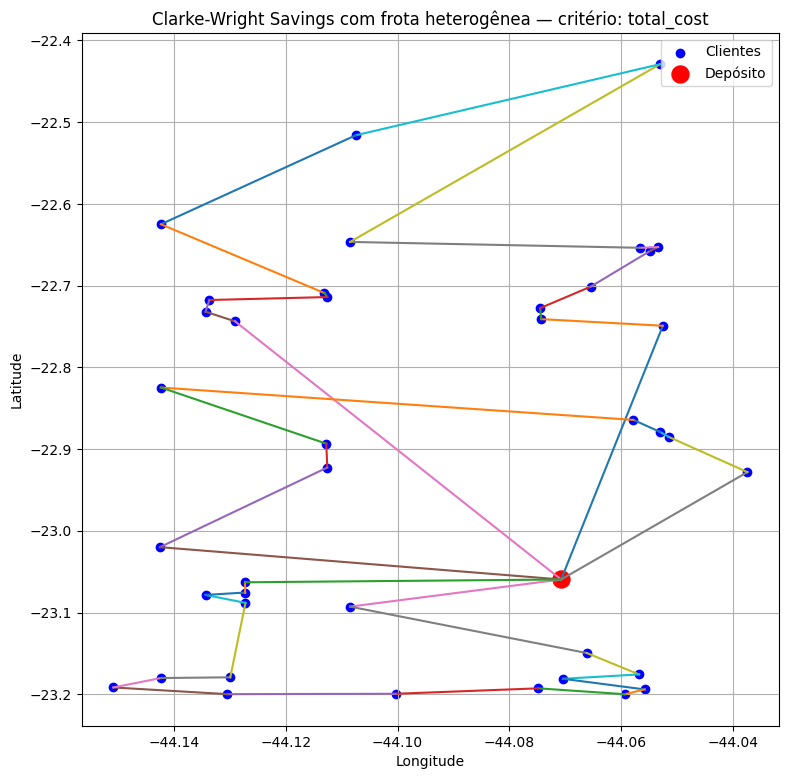

In [ ]:
# ============================================================
# (19) VISUALIZAÇÃO DAS ROTAS
# ============================================================

def plot_solution(solution, nodes, title):
    x_coords = nodes["lon"].values
    y_coords = nodes["lat"].values

    plt.figure(figsize=(9, 9))
    plt.scatter(x_coords[1:], y_coords[1:], color="blue", label="Clientes")
    plt.scatter(x_coords[0], y_coords[0], color="red", s=150, label="Depósito")

    for item in solution:
        route = item["route"]
        for i in range(len(route) - 1):
            a = route[i]
            b = route[i + 1]
            plt.plot([x_coords[a], x_coords[b]], [y_coords[a], y_coords[b]])

    plt.title(title)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.grid(True)
    plt.legend()
    plt.show()

plot_solution(
    solution_cw_het,
    nodes,
    f"Clarke-Wright Savings com frota heterogênea — critério: {criterion}"
)

In [ ]:
# ============================================================
# (20) COMPARAÇÃO ENTRE CRITÉRIOS DE DECISÃO
# ============================================================
# Agora comparamos:
# - menor custo total da rota
# - menor custo por cliente atendido

results_compare = []

for crit in ["total_cost", "cost_per_client"]:
    start = time.time()

    sol = clarke_wright_heterogeneous(
        D=D,
        q=q,
        s=s,
        Q=Q,
        f=f,
        cost_per_km=cost_per_km,
        v_kmh=v_kmh,
        H=H,
        criterion=crit,
        verbose=False
    )

    elapsed = time.time() - start

    met = solution_metrics_heterogeneous(
        solution=sol,
        D=D,
        q=q,
        s=s,
        cost_per_km=cost_per_km,
        fixed_costs=f,
        H=H,
        v_kmh=v_kmh
    )

    met["criterion"] = crit
    met["elapsed_s"] = elapsed
    results_compare.append(met)

df_compare_cw = pd.DataFrame(results_compare)
df_compare_cw

,n_routes,n_fio,n_vuc,total_distance_km,total_cost_rs,total_time_h,routes_violating_H,criterion,elapsed_s
0,3,2,1,268.530066,1452.795099,16.713252,0,total_cost,0.023964
1,3,2,1,268.530066,1452.795099,16.713252,0,cost_per_client,0.020352


In [ ]:
# ============================================================
# (21) DISCUSSÃO FINAL
# ============================================================
# Pontos para discussão:
# 1) Quantas fusões o algoritmo conseguiu realizar?
# 2) O uso da jornada reduziu o número de fusões possíveis?
# 3) A solução final usou mais FIO ou mais VUC?
# 4) O critério adotado alterou a composição da frota?
# 5) A solução final ficou mais consolidada do que no NN?

print("Encerramento da prática:")
print("- Analise a estrutura das rotas finais.")
print("- Compare a composição da frota escolhida.")
print("- Observe a influência da jornada de 8h sobre as fusões.")
print("- Compare os dois critérios de escolha do veículo.")
print("- Discuta as diferenças entre Savings e Nearest Neighbor.")

Encerramento da prática:
- Analise a estrutura das rotas finais.
- Compare a composição da frota escolhida.
- Observe a influência da jornada de 8h sobre as fusões.
- Compare os dois critérios de escolha do veículo.
- Discuta as diferenças entre Savings e Nearest Neighbor.


In [ ]:
# ============================================================
# (22) SALVAR SOLUÇÃO CLARKE-WRIGHT PARA A AULA DE BUSCA LOCAL
# ============================================================
# A solução gerada pelo Clarke-Wright Savings será usada como
# ponto de partida para a próxima aula, em que aplicaremos
# heurísticas de melhoria como 2-opt e relocate.
#
# Por isso, vamos salvar a solução em um arquivo JSON.

import json
from google.colab import files

def save_solution_json(solution, filename):
    with open(filename, "w", encoding="utf-8") as f:
        json.dump(solution, f, indent=4, ensure_ascii=False)

save_solution_json(solution_cw_het, "solution_cw_het.json")

files.download("solution_cw_het.json")

print("Arquivo solution_cw_het.json salvo e disponível para download.")